# 04 - Control mechanism: action timing

Buraya kadarki notebook'lar "ne kadar iyi dengeledi" diye sordu. Bu notebook
farkli bir sey soruyor: **kisi ne zaman tepki veriyor?** Ludolph et al. (2017)
insanlarin ogrendikce eylemlerinin olaydan *sonra* olmaktan cikip olaydan
*once* olmaya kaydigini bulmustu -- refleksten ongoruye gecis.

Yontem kararlari ve gerekceler: `Documentation/Yontem/05_Action_Timing.md`.
Fizibilite orada dogrulanmisti; bu notebook uygulama.

Olcut: pole belirli bir aciyi **duserken** gectigi ana ortalanmis input
segmentlerinin ortalamasi, ve o ortalama egrinin **sifiri kestigi lag**.
Negatif = predictive (kuvvet olaydan once yon degistirmis),
pozitif = reactive.

**Iki olay tablosu var, karistirmayin:**

| | Nerede tanimli | Kim uretiyor |
|---|---|---|
| `input_events` | girdi tarafinda (notr banddan cikis, yon degistirme) | NB02, `build.detect_input_events` |
| `state_events` | durum tarafinda (pole tamsayi aciyi duserken geciyor) | bu notebook, `timing.build_segments` |

In [1]:
%pip install -q pyyaml pandas numpy pyarrow matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

# Aktif veri seti. config.yaml -> datasets. Setler birbirine karismaz:
# her set kendi data/<dataset>/{raw,interim,processed} agacinda durur.
DATASET = "pilot2"

ANALYSIS_ROOT = Path.cwd()
for _ in range(4):
    if (ANALYSIS_ROOT / "config.yaml").exists():
        break
    ANALYSIS_ROOT = ANALYSIS_ROOT.parent
sys.path.insert(0, str(ANALYSIS_ROOT))

from src import timing as tm
from src import performance as perf

from src.dataset import load_config, dirs

config, ANALYSIS_ROOT = load_config(DATASET, ANALYSIS_ROOT)
RAW_DIR, INTERIM_DIR, PROCESSED_DIR = dirs(config, ANALYSIS_ROOT)
print(f"veri seti: {config['dataset']}  ({config['dataset_label']})")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})

df_samples = pd.read_parquet(INTERIM_DIR / "samples_built.parquet")
MAIN = config["timing"]["main_band_center_deg"]
HW = config["timing"]["band_half_width_deg"]
LAGS = tm.lag_axis(config)

print(f"sample     {len(df_samples):,}")
print(f"katilimci  {df_samples.participant_id.nunique()}")
print(f"ana bant   |theta| = {MAIN} +- {HW} derece")
print(f"segment    {LAGS.size} nokta, {LAGS[0]*1000:.0f} .. {LAGS[-1]*1000:.0f} ms")

veri seti: pilot2  (Pilot 2 -- 9 katilimci, 2-3 Eylul 2026)
sample     623,700
katilimci  9
ana bant   |theta| = 10 +- 2 derece
segment    61 nokta, -500 .. 500 ms


## 1. state_events: olaylari bul, segmentleri cikar

Ludolph'un prosedurunun i. ve iii. adimlari:

1. Olay = pole tamsayi aciyi **duserken** geciyor. Gecis ani frame'ler
   arasinda kaliyorsa lineer interpolasyonla alt-frame cozunurlukte
   kestiriliyor. Pole yukari donuyorsa gecis elenir -- karsi-aksiyon
   gerektirmiyor.
2. Her olaya ortalanmis +-0.5 s'lik input segmenti.

Bizim iki eklememiz:

- **Segment kesintisiz aktif parcanin disina tasiyorsa tamamen atilir.**
  Reset satirlarinda `applied_force_n` sifira zorlanmis (kayit sorunu 2),
  oradaki degerler sahte; kirpmak yerine segmenti dusuruyoruz.
- **Negatif acilarin segmentleri isaret cevrilerek havuzlanir.** +10 ile -10
  ayni olayin aynasi; segment sayisi ikiye katlaniyor, yorum degismiyor.

In [3]:
events, X = tm.build_segments(df_samples, config)
events = tm.add_velocity_strata(events, config)
meta = tm.add_trial_window(tm.segment_meta(events), config)

print(f"olay    {len(events):,}")
print(f"segment {X.shape[0]:,}  ({X.shape[1]} nokta, {X.dtype})")
display(events.groupby("band_center").agg(
    olay=("segment_fits", "size"),
    segment=("segment_fits", "sum"),
    atilan_yuzde=("segment_fits", lambda s: 100 * (1 - s.mean())),
    ort_omega=("abs_omega_event", "mean"),
).round(1))

olay    66,420
segment 56,050  (61 nokta, float32)


,olay,segment,atilan_yuzde,ort_omega
band_center,,,,
5,23569,20694,12.2,42.8
10,19024,16539,13.1,49.7
15,13612,11153,18.1,61.9
20,10215,7664,25.0,73.6


### Tek bir olay neye benziyor

Soyut kalmasin: asagida gercek bir olay ve cevresindeki ham satirlar.
`olaya_gore_ms` sutunu olay anina gore zamani veriyor. Olay tam olarak
frame'lerin **arasinda** bir yerde: aci tam 10.000'e frame basinda denk
gelmiyor, bu yuzden alt-frame interpolasyon gerekiyor.

In [4]:
band = meta[(meta.band_center == MAIN) & (meta.participant_id == "P001")]
# ornek icin gorulur bir yon degistirme iceren bir olay seciliyor
vis = band.index[(X[band.index.to_numpy()].min(axis=1) < -.15)
                 & (X[band.index.to_numpy()].max(axis=1) > .15)]
ex = meta.loc[vis[0]]

print(f"{ex.participant_id} / {ex.trial_id} / episode {int(ex.episode)} / {ex.noise_level_id}")
print(f"aci seviyesi   {ex.angle_level:+.0f} derece")
print(f"olay ani       t = {ex.t_event_s:.4f} s")
print(f"olay anindaki  omega = {ex.omega_event:+.1f} deg/s -> tabaka {ex.vel_stratum}")
print("theta ile omega ayni isaretli, yani pole DUSUYOR -- olay sayiliyor.\n")
display(tm.event_context(df_samples, ex, n=5))

P001 / T004 / episode 1 / N3
aci seviyesi   -12 derece
olay ani       t = 4.0216 s
olay anindaki  omega = -14.3 deg/s -> tabaka slow
theta ile omega ayni isaretli, yani pole DUSUYOR -- olay sayiliyor.



,sample_index,t_trial_s,pole_angle_deg,pole_angular_velocity_deg_s,input_applied,action,olaya_gore_ms
5395,235,3.933,-10.809,-12.648,0.000,I,-88.3
5396,236,3.950,-11.022,-12.955,0.000,I,-71.6
5397,237,3.967,-11.241,-13.268,0.000,I,-54.9
5398,238,3.983,-11.465,-13.587,0.000,I,-38.3
5399,239,4.000,-11.694,-13.912,0.000,I,-21.6
5400,240,4.017,-11.928,-14.243,0.000,I,-4.9
5401,241,4.033,-12.169,-14.581,0.000,I,11.7
5402,242,4.050,-12.414,-14.926,0.000,I,28.4
5403,243,4.067,-12.673,-16.128,0.064,D,45.1
5404,244,4.083,-12.967,-19.148,0.202,D,61.7


Bu olaydan cikan segment `input_applied`'in olay anina gore -500..+500
ms'lik seyri (isaret hizalanmis: negatif acili olaylarda isaret cevriliyor,
boylece "duzeltici yon" her zaman + tarafta).

Tek segment yeterli degil. Bir sonraki hucrede ayni katilimcinin baska bir
olayi var: katilimci o bir saniyenin tamamini elini oynatmadan geciriyor,
segment bastan sona sifir. Aktif orneklerin %73.9'u tam sifir. Olcut o
yuzden tek segmentten degil **binlerce segmentin ortalamasindan** okunuyor.

In [5]:
seg = X[ex.name]
print("A) yukaridaki olay (her 5 frame'de bir, -500 -> +500 ms):")
print("   " + "  ".join(f"{v:+.2f}" for v in seg[::5]))
print(f"   tam sifir olan ornek: {(seg == 0).mean():.0%}")

quiet = band.index[(X[band.index.to_numpy()] == 0).all(axis=1)]
print("\nB) ayni katilimcinin hic dokunmadigi bir olay:")
print("   " + "  ".join(f"{v:+.2f}" for v in X[quiet[0]][::5]))
print(f"   boyle segment: {len(quiet)} / {len(band)} (bu katilimci, bu bant)")

pool = X[meta.index[meta.band_center == MAIN].to_numpy()].mean(axis=0)
print("\nC) bandin butun segmentlerinin ortalamasi:")
print("   " + "  ".join(f"{v:+.2f}" for v in pool[::5]))
print("   negatiften pozitife tek gecis -> action timing bu gecisin lag'i")

A) yukaridaki olay (her 5 frame'de bir, -500 -> +500 ms):
   -0.00  -0.00  -0.00  -0.00  -0.00  -0.00  -0.00  -0.32  -0.52  -0.00  -0.00  -0.00  +0.52
   tam sifir olan ornek: 74%

B) ayni katilimcinin hic dokunmadigi bir olay:
   -0.00  -0.00  -0.00  -0.00  -0.00  -0.00  -0.00  -0.00  -0.00  -0.00  -0.00  -0.00  -0.00
   boyle segment: 45 / 2094 (bu katilimci, bu bant)

C) bandin butun segmentlerinin ortalamasi:
   -0.11  -0.13  -0.12  -0.09  -0.04  -0.01  +0.04  +0.14  +0.19  +0.21  +0.19  +0.17  +0.16
   negatiften pozitife tek gecis -> action timing bu gecisin lag'i


## 2. Hiz tabakalama

Ludolph olay anindaki acisal hizi %20-%80 kuantillerinin disinda kalan
gecisleri **atiyor**. Sebep gecerli: pole 10 dereceden yavasca geciyorsa
gereken duzeltme baska, savrularak geciyorsa baska; ikisi ayni ortalamaya
girerse egri bulaniklasir.

Biz atmiyoruz, **tabakaliyoruz** (yontem karari 3.3). Orta bant onun
sakladigi kume; yavas ve hizli ayrica raporlanabiliyor. Kuantil
**katilimci x aci seviyesi** icinde, butun kosullar havuzlanarak
hesaplaniyor -- kosul icinden hesaplansaydi eleme kosula uyarlanir ve artik
ayni hiz bandi karsilastirilmazdi.

Ikinci hucre confound kontrolu: **gurultu, olay anindaki hiz dagilimini
degistiriyor mu?** Degistirseydi tabakalar arasi her karsilastirma kosula
bulasirdi.

In [6]:
m10 = meta[meta.band_center == MAIN]
X10 = X[m10.index.to_numpy()]
m10 = m10.reset_index(drop=True)

display(m10.groupby("vel_stratum", observed=True).agg(
    segment=("abs_omega_event", "size"),
    omega_ort=("abs_omega_event", "mean"),
    omega_min=("abs_omega_event", "min"),
    omega_max=("abs_omega_event", "max"),
).round(1))

print("Kosula gore olay anindaki |omega| (deg/s):")
display(tm.velocity_by_condition(m10))

,segment,omega_ort,omega_min,omega_max
vel_stratum,,,,
slow,3542,9.3,0.0,30.4
mid,10581,39.1,7.8,140.3
fast,2416,86.5,37.6,187.4


Kosula gore olay anindaki |omega| (deg/s):


,n_katilimci,ortalama,merkezlenmis
noise_level_id,,,
no_noise,9,36.680,-0.522
N1,9,36.932,-0.270
N2,9,38.240,1.037
N3,9,35.885,-1.318
N4,9,38.277,1.074


## 3. Ortalama egri sagliyor mu

Yontemin sessiz varsayimi: ortalama segment duzgun bir S cizer ve sifiri
**bir kez** keser. Bizde aktif orneklerin %73.9'u tam sifir (yayli analog
kol merkeze donuyor), o yuzden bu bir varsayim degil kontrol edilmesi
gereken bir sey.

In [7]:
st = tm.curve_stats(X10, config)
boot = tm.bootstrap_zc(X10, config)
print(f"segment        {st['n_segment']:,}")
print(f"sifir gecisi   {st['zc_ms']:+.1f} ms   (bootstrap %95: "
      f"{boot['zc_lo_ms']:+.1f} .. {boot['zc_hi_ms']:+.1f} ms)")
print(f"gecis sayisi   {st['n_crossing']}  (yukselen {st['n_rising']})")
print(f"genlik         {st['amplitude']:.4f}")
print(f"ortalamanin standart hatasi (max)  {st['sem_max']:.4f}"
      f"   -> genlik/sh = {st['amp_over_sem']:.0f}x")
print(f"segmentlerdeki tam sifir orani     {st['zero_frac']:.1%}")

segment        16,539
sifir gecisi   -43.5 ms   (bootstrap %95: -46.5 .. -39.7 ms)
gecis sayisi   1  (yukselen 1)
genlik         0.3422
ortalamanin standart hatasi (max)  0.0027   -> genlik/sh = 128x
segmentlerdeki tam sifir orani     68.6%


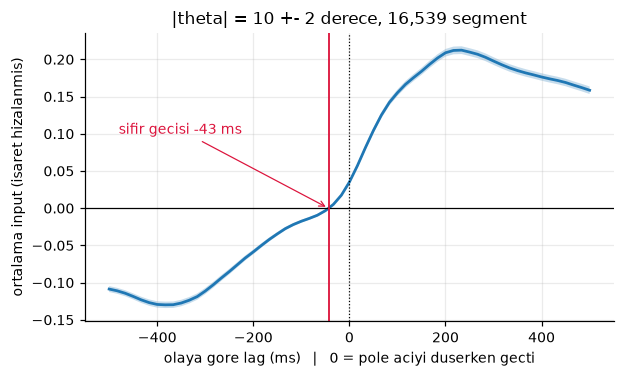

In [8]:
mean_curve = X10.mean(axis=0)
sem = X10.std(axis=0, ddof=1) / np.sqrt(X10.shape[0])

fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.fill_between(LAGS * 1000, mean_curve - 1.96 * sem, mean_curve + 1.96 * sem,
                alpha=.25, lw=0)
ax.plot(LAGS * 1000, mean_curve, lw=1.8)
ax.axhline(0, color="k", lw=.8)
ax.axvline(0, color="k", lw=.8, ls=":")
ax.axvline(st["zc_ms"], color="crimson", lw=1.2)
ax.annotate(f"sifir gecisi {st['zc_ms']:+.0f} ms", (st["zc_ms"], 0),
            xytext=(-480, .10), color="crimson",
            arrowprops=dict(arrowstyle="->", color="crimson", lw=.8))
ax.set_xlabel("olaya gore lag (ms)   |   0 = pole aciyi duserken gecti")
ax.set_ylabel("ortalama input (isaret hizalanmis)")
ax.set_title(f"|theta| = {MAIN} +- {HW} derece, {X10.shape[0]:,} segment")
plt.show()

Egri temiz: negatiften basliyor, tek seferde sifiri kesiyor, doyuma gidip
hafifce geriliyor. Bantta orneklerin buyuk kismi tam sifir olmasina ragmen
ortalama purzsuz -- yon degistirme ani segmentler arasinda biraz kaydigi
icin ortalama surekli bir rampa uretiyor.

Asil granulariteye, yani **katilimci x kosul** hucresine bakalim: olcut
orada da tanimli mi?

In [9]:
cells_pc = tm.timing_cells(m10, X10, ["participant_id", "noise_level_id"], config)
print(f"hucre                {len(cells_pc)}")
print(f"yetersiz segment     {int(cells_pc.yetersiz.sum())}")
print(f"tek gecisli          {int((cells_pc.n_crossing == 1).sum())}")
print(f"gercek yon degistirme (mean_pre < 0 < mean_post)  "
      f"{int(cells_pc.reversal_ok.sum())}")
print(f"guvenilir            {int(cells_pc['guvenilir'].sum())}")
print(f"hucre basina segment: min {int(cells_pc.n_segment.min())}, "
      f"medyan {int(cells_pc.n_segment.median())}, max {int(cells_pc.n_segment.max())}")

hucre                45
yetersiz segment     0
tek gecisli          44
gercek yon degistirme (mean_pre < 0 < mean_post)  45
guvenilir            45
hucre basina segment: min 215, medyan 336, max 642


## 4. Kosul ekseni: gurultu zamanlamayi bozuyor mu

Olcek NB03 ile ayni: **katilimci ici merkezlenmis** profil, baseline'a gore
eslesmis fark ve dz. Test yok, betimleyici (istatistik NB06'nin isi ve
action timing zaten karar metrik setinde degil).

In [10]:
display(tm.condition_profile(cells_pc))
print("Baseline (no_noise) ile eslesmis fark:")
display(perf.baseline_agreement(cells_pc, "zc_ms", config))

,n_katilimci,ham,merkezlenmis,sem,segment
noise_level_id,,,,,
no_noise,9,-77.520,-11.542,11.044,3360
N1,9,-59.949,6.029,9.504,3264
N2,9,-57.931,8.047,10.380,3403
N3,9,-74.167,-8.190,12.578,3210
N4,9,-60.322,5.656,9.895,3302


Baseline (no_noise) ile eslesmis fark:


,baseline_farki,dz,n_kotu,n
kosul,,,,
N1,17.571,0.441,NaN,9
N2,19.589,0.381,NaN,9
N3,3.353,0.053,NaN,9
N4,17.199,0.351,NaN,9


In [11]:
print("Kosul yayilimi mi kisi yayilimi mi buyuk:")
display(tm.spread_comparison(cells_pc).to_frame("ms"))

w = cells_pc.pivot(index="participant_id", columns="noise_level_id", values="zc_ms")
cen = w.sub(w.mean(axis=1), axis=0)
print("Merkezlenmis profil, ortalama vs medyan (ms):")
display(pd.DataFrame({"ortalama": cen.mean(), "medyan": cen.median(),
                      "P007 haric ort": cen.drop("P007").mean()}).round(1).T)
print(f"Kisi ici, kosullar arasi sd: {cen.std(axis=1).mean():.1f} ms")

Kosul yayilimi mi kisi yayilimi mi buyuk:


,ms
kisi_ortalamasi_min,-143.47
kisi_ortalamasi_max,-5.80
kisi_yayilimi,137.68
kisi_sd,45.55
kosul_yayilimi,19.59
kosul_sd,9.13


Merkezlenmis profil, ortalama vs medyan (ms):


noise_level_id,no_noise,N1,N2,N3,N4
ortalama,-11.5,6.0,8.0,-8.2,5.7
medyan,-10.4,8.3,10.4,4.9,5.3
P007 haric ort,-17.4,3.9,8.1,-7.3,12.6


Kisi ici, kosullar arasi sd: 30.5 ms


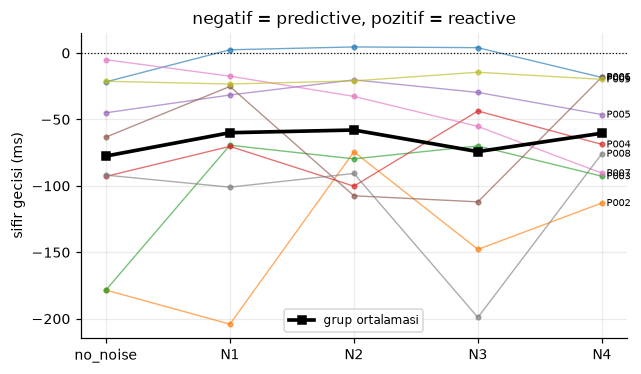

In [12]:
fig, ax = plt.subplots(figsize=(6.4, 3.6))
for p, r in w.iterrows():
    ax.plot(range(len(r)), r.to_numpy(), marker="o", ms=3, lw=.9, alpha=.65)
    ax.annotate(p, (len(r) - 1, r.iloc[-1]), fontsize=6.5, xytext=(3, -2),
                textcoords="offset points")
ax.plot(range(w.shape[1]), w.mean().to_numpy(), color="k", lw=2.4, marker="s",
        ms=5, label="grup ortalamasi")
ax.axhline(0, color="k", lw=.8, ls=":")
ax.set_xticks(range(w.shape[1]))
ax.set_xticklabels(list(w.columns))
ax.set_ylabel("sifir gecisi (ms)")
ax.set_title("negatif = predictive, pozitif = reactive")
ax.legend(fontsize=8)
plt.show()

Figur tek basina yeterli: **kisiler arasi yayilim, kosullar arasi yayilimin
bir mertebe ustunde.** Ayni kisinin bes kosulu birbirine yakin duruyor,
kisiler ise birbirinden cok uzak.

P007 tek basina digerlerinin ters tarafinda. Bu, NB02'deki aksiyon
dagiliminda da gorulmustu: P007'nin D (bozucu) orani %15.2, digerlerinde
~%2. Ayni kisinin iki bagimsiz olcude de ayrismasi, olcunun gercek bir sey
yakaladigina isaret.

## 5. Ogrenme ekseni

Duvar saati yok: `t_trial_s` her trial'da sifirlaniyor ve metadata'da trial
zaman damgasi yok. Ama gerek de yok -- **`trial_order` zaten bir zaman
ekseni**: tam kayitli, sirali, denemeler arka arkaya yapiliyor. Ludolph'un
2 dakikalik penceresi bizde ~6 denemeye denk geliyor; 10'luk pencere
kullaniyoruz (kosullar havuzlanir).

In [13]:
cells_tw = tm.timing_cells(m10, X10, ["participant_id", "trial_window"], config)
print("Butun tabakalar:")
display(tm.window_profile(cells_tw))
slopes, ozet = tm.learning_slopes(cells_tw)
print("Katilimci basina dogrusal egim (ms / pencere):")
display(ozet.to_frame("deger").T)

Butun tabakalar:


,n_katilimci,segment,ortalama,medyan,sd
trial_window,,,,,
1-10,9,404.00,-53.66,-56.71,42.85
11-20,9,373.00,-74.05,-86.19,43.52
21-30,8,329.38,-62.47,-44.28,56.86
31-40,9,348.44,-62.71,-49.94,49.69
41-50,9,353.89,-104.39,-97.21,77.19


Katilimci basina dogrusal egim (ms / pencere):


,ortalama_egim,medyan_egim,sd,dz,negatif_yonde,n
deger,-9.012,-6.954,14.235,-0.633,7.0,9.0


Ortalama tabloda net bir kayma var, seans ilerledikce daha ongorulu.
Ludolph'un buldugu sey tam olarak bu. Ama iki kontrol gerekiyor, ikisi de
bu iddiayi zayiflatiyor.

**Kontrol 1: kompozisyon.** Katilimcilar ilerledikce daha iyi dengeliyor,
yani gecisler yavasliyor. Yavas ve hizli gecislerin zamanlamasi cok farkli
(bkz. 6). Yani "kayma" sadece olay karisiminin degismesi olabilir.

In [14]:
display(m10.groupby("trial_window", observed=True).agg(
    olay=("abs_omega_event", "size"),
    omega=("abs_omega_event", "mean"),
    yavas_yuzde=("vel_stratum", lambda s: 100 * (s == "slow").mean()),
    hizli_yuzde=("vel_stratum", lambda s: 100 * (s == "fast").mean()),
).round(1))

mid = m10[m10.vel_stratum == "mid"]
Xmid = X10[mid.index.to_numpy()]
mid = mid.reset_index(drop=True)
cells_mid = tm.timing_cells(mid, Xmid, ["participant_id", "trial_window"], config)
print("Sadece orta hiz tabakasinda (kompozisyon sabit):")
display(tm.window_profile(cells_mid))

,olay,omega,yavas_yuzde,hizli_yuzde
trial_window,,,,
1-10,3636,43.0,20.5,20.1
11-20,3357,39.2,21.7,14.6
21-30,3225,40.6,22.5,16.6
31-40,3136,36.9,20.8,9.3
41-50,3185,38.0,21.7,11.6


Sadece orta hiz tabakasinda (kompozisyon sabit):


,n_katilimci,segment,ortalama,medyan,sd
trial_window,,,,,
1-10,9,239.89,-124.04,-147.31,108.52
11-20,9,237.89,-134.65,-65.85,139.51
21-30,9,218.22,-133.76,-140.54,123.82
31-40,9,243.67,-100.20,-73.44,91.38
41-50,9,236.00,-147.14,-144.16,108.83


Hizli gecislerin payi seans boyunca duzenli olarak dusuyor, yani
kompozisyon gercekten degisiyor. Ama orta tabaka **tek basina** alindiginda
da kayma duruyor; demek ki etki tamamen kompozisyon degil.

**Kontrol 2: kac kiside var.** Asil sinav bu.

In [15]:
wt = cells_mid.pivot(index="participant_id", columns="trial_window", values="zc_ms")
display(wt.round(0))
slopes_mid, ozet_mid = tm.learning_slopes(cells_mid)
display(ozet_mid.to_frame("orta tabaka").T)

# Pilot 1'de bu liste elle P007/P012 idi (o setin iki aykiri kisisi).
# Veri setinden bagimsiz olsun diye: ortalama zc'si medyandan en cok
# sapan iki kisi. Soru ayni -- ogrenme kaymasi bu ikisi olmadan da
# duruyor mu.
_m = cells_mid.groupby("participant_id").zc_ms.mean()
drop = list((_m - _m.median()).abs().nlargest(2).index)
print(f"{', '.join(drop)} haric pencere ortalamalari:")
display(tm.window_profile(cells_mid[~cells_mid.participant_id.isin(drop)])
        [["n_katilimci", "ortalama", "medyan"]])

trial_window,1-10,11-20,21-30,31-40,41-50
participant_id,,,,,
P001,19.0,-10.0,13.0,-16.0,-7.0
P002,-258.0,-391.0,-386.0,-271.0,-345.0
P003,-207.0,-260.0,-217.0,-206.0,-250.0
P004,-232.0,-66.0,-89.0,-94.0,-144.0
P005,-41.0,-24.0,-32.0,-73.0,-192.0
P006,-147.0,-59.0,-187.0,-55.0,-169.0
P007,-13.0,-115.0,-154.0,-31.0,-16.0
P008,-212.0,-276.0,-141.0,-151.0,-124.0
P009,-26.0,-10.0,-12.0,-4.0,-76.0


,ortalama_egim,medyan_egim,sd,dz,negatif_yonde,n
orta tabaka,-1.174,-3.852,18.002,-0.065,6.0,9.0


P002, P001 haric pencere ortalamalari:


,n_katilimci,ortalama,medyan
trial_window,,,
1-10,7,-125.43,-147.31
11-20,7,-115.78,-65.85
21-30,7,-118.75,-140.54
31-40,7,-87.88,-73.44
41-50,7,-138.86,-144.16


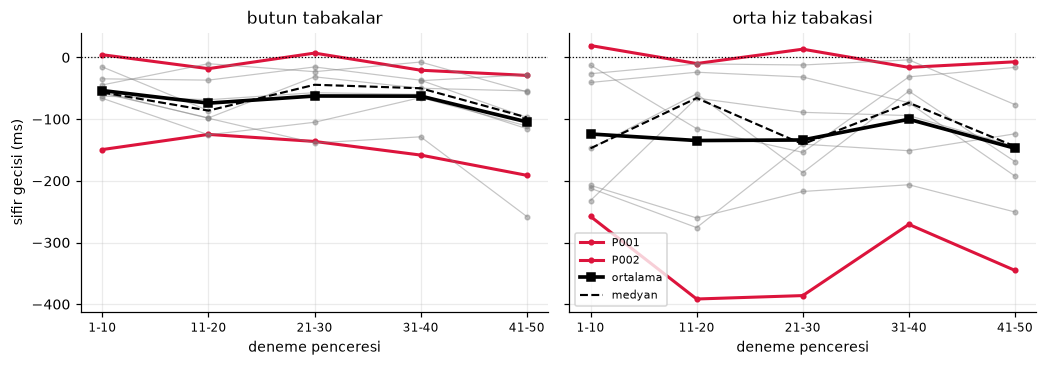

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.4), sharey=True)
tabs = [("butun tabakalar", cells_tw.pivot(index="participant_id",
                                           columns="trial_window", values="zc_ms")),
        ("orta hiz tabakasi", wt)]
for ax, (title, tab) in zip(axes, tabs):
    for p, r in tab.iterrows():
        hi = p in drop
        ax.plot(range(len(r)), r.to_numpy(), marker="o", ms=3,
                lw=2.0 if hi else .8, alpha=1 if hi else .45,
                color="crimson" if hi else "gray",
                label=p if hi else None)
    ax.plot(range(tab.shape[1]), tab.mean().to_numpy(), color="k", lw=2.4,
            marker="s", ms=5, label="ortalama")
    ax.plot(range(tab.shape[1]), tab.median().to_numpy(), color="k", lw=1.4,
            ls="--", label="medyan")
    ax.axhline(0, color="k", lw=.8, ls=":")
    ax.set_xticks(range(tab.shape[1]))
    ax.set_xticklabels(list(tab.columns), fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("deneme penceresi")
axes[0].set_ylabel("sifir gecisi (ms)")
axes[1].legend(fontsize=7.5)
plt.tight_layout()
plt.show()

**Sonuc: ogrenme kaymasi saglam degil.** Ortalamayi surukleyen iki kisi
P007 ve P012; ikisi de seansa *pozitif* (reaktif) baslayip negatife
kayiyor. Onlar cikarilinca pencere ortalamalari duzlesiyor ve medyan zaten
bastan duz.

Alternatif aciklama basit: bu iki kisi ilk penceresinde atipik bir yerde
basladi ve sonra grubun geneline yaklasti -- regression to the mean.
Ayrica hucre ici gurultu buyuk (kisi x pencere sd ~100 ms), tek pencereden
okunan deger oynak.

Bu, `05_Action_Timing.md` 3.2'deki beklenti uyarisiyla tutarli: Ludolph bir
saatten uzun, yercekimi kademeli artan bir gorevde ogrenme olcmustu. Bizde
tek oturum, 21 dakika, sabit g = 1.0.

## 6. Hiz tabakalari

Burada beklenmedik bir sey cikti ve olcunun tanimini ilgilendiriyor.

In [17]:
rows = []
curves = {}
for s in ["slow", "mid", "fast"]:
    idx = m10.index[m10.vel_stratum == s].to_numpy()
    st_s = tm.curve_stats(X10[idx], config)
    curves[s] = X10[idx].mean(axis=0)
    rows.append({"tabaka": s, **{k: st_s[k] for k in
                 ["n_segment", "zc_ms", "n_crossing", "amplitude",
                  "amp_over_sem", "mean_pre", "mean_post", "reversal_ok",
                  "guvenilir"]}})
display(pd.DataFrame(rows).set_index("tabaka").round(3))

print("Ayni tabakalar hucre duzeyinde hesaplanirsa:")
display(tm.timing_cells(m10, X10, ["participant_id", "vel_stratum"], config)
        .groupby("vel_stratum", observed=True)
        .agg(n=("zc_ms", "size"), zc_ort=("zc_ms", "mean"),
             genlik=("amplitude", "mean"),
             gercek_reversal=("reversal_ok", "sum"),
             guvenilir=("guvenilir", "sum")).round(1))

,n_segment,zc_ms,n_crossing,amplitude,amp_over_sem,mean_pre,mean_post,reversal_ok,guvenilir
tabaka,,,,,,,,,
slow,3542,-499.368,1,0.097,21.903,-0.000,0.078,True,True
mid,10581,-43.087,1,0.318,98.834,-0.113,0.158,True,True
fast,2416,-17.584,1,0.875,103.577,-0.248,0.282,True,True


Ayni tabakalar hucre duzeyinde hesaplanirsa:


,n,zc_ort,genlik,gercek_reversal,guvenilir
vel_stratum,,,,,
fast,9,-22.0,0.9,8,8
mid,9,-114.9,0.3,9,9
slow,9,-377.4,0.1,5,2


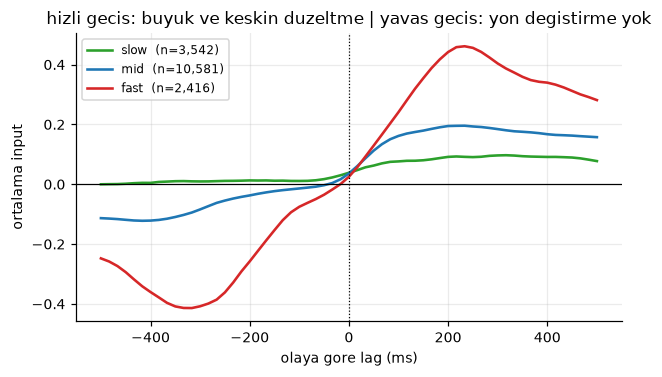

In [18]:
fig, ax = plt.subplots(figsize=(6.4, 3.4))
for s, c in zip(["slow", "mid", "fast"], ["tab:green", "tab:blue", "tab:red"]):
    ax.plot(LAGS * 1000, curves[s], lw=1.7, color=c,
            label=f"{s}  (n={int((m10.vel_stratum == s).sum()):,})")
ax.axhline(0, color="k", lw=.8)
ax.axvline(0, color="k", lw=.8, ls=":")
ax.set_xlabel("olaya gore lag (ms)")
ax.set_ylabel("ortalama input")
ax.set_title("hizli gecis: buyuk ve keskin duzeltme | yavas gecis: yon degistirme yok")
ax.legend(fontsize=8)
plt.show()

**Yavas tabakada sifir gecisi yok.** Ortalama egri bastan sona pozitif
kaliyor: katilimci pole yavasca aciyi gecerken zaten duzeltici yonde
itiyor, ayrica bir "yon degistirme" olmuyor. Yani orada action timing
**tanimsiz** -- olcut ancak gercek bir reversal varsa var.

Bu yuzden `curve_stats` iki bayrak uretiyor: `reversal_ok` (ortalama egri
negatiften pozitife geciyor mu) ve `guvenilir` (bunun yaninda genlik,
ortalamanin standart hatasinin en az `min_amp_sem_ratio` kati mi). Hucre
duzeyinde bakildiginda yavas tabakadaki "sifir gecisi" degerleri duz bir
egrinin gurultusunden cikiyor ve sacma sapan ortalamalar uretiyor; bayrak
bunlari isaretliyor.

Hizli tabaka ise tersi: genlik orta tabakanin birkac kati, sifir gecisi
sifira cok daha yakin. Buyuk, gec ama sert duzeltme.

## 7. Action variability

Ludolph'un ikinci olcusu: sifir gecisi cevresinde +-60 ms'lik pencerede
force'un standart sapmasi. Bizde `05_Action_Timing.md` 8'de "henuz test
edilmedi" diye duruyordu.

In [19]:
for col in ["variability", "amplitude", "var_norm"]:
    print(col)
    display(tm.condition_profile(cells_pc, col)[["ham", "merkezlenmis", "sem"]])
print("Baseline ile eslesmis fark -- variability:")
display(perf.baseline_agreement(cells_pc, "variability", config))
print("Genlige bolunmus hali (var_norm):")
display(perf.baseline_agreement(cells_pc, "var_norm", config))

variability


,ham,merkezlenmis,sem
noise_level_id,,,
no_noise,0.122,-0.006,0.008
N1,0.138,0.010,0.009
N2,0.129,0.000,0.007
N3,0.122,-0.007,0.004
N4,0.131,0.002,0.006


amplitude


,ham,merkezlenmis,sem
noise_level_id,,,
no_noise,0.367,0.002,0.013
N1,0.360,-0.005,0.026
N2,0.376,0.011,0.015
N3,0.351,-0.013,0.021
N4,0.369,0.005,0.014


var_norm


,ham,merkezlenmis,sem
noise_level_id,,,
no_noise,0.352,-0.031,0.022
N1,0.442,0.058,0.047
N2,0.362,-0.022,0.034
N3,0.379,-0.005,0.038
N4,0.383,-0.000,0.037


Baseline ile eslesmis fark -- variability:


,baseline_farki,dz,n_kotu,n
kosul,,,,
N1,0.016,0.403,NaN,9
N2,0.006,0.182,NaN,9
N3,-0.000,-0.021,NaN,9
N4,0.009,0.236,NaN,9


Genlige bolunmus hali (var_norm):


,baseline_farki,dz,n_kotu,n
kosul,,,,
N1,0.089,0.504,NaN,9
N2,0.009,0.088,NaN,9
N3,0.026,0.219,NaN,9
N4,0.031,0.193,NaN,9


In [20]:
tmet = pd.read_parquet(INTERIM_DIR / "trial_metrics.parquet")
pc_perf = tmet.groupby(["participant_id", "noise_level_id"])[
    ["control_effort", "mae_angle_deg"]].mean().reset_index()
mrg = cells_pc.merge(pc_perf, on=["participant_id", "noise_level_id"])


def cen_(col):
    return mrg[col] - mrg.groupby("participant_id")[col].transform("mean")


print("Katilimci ici korelasyon (NB03 metrikleriyle):")
display(pd.DataFrame({
    m: {"control_effort": cen_(m).corr(cen_("control_effort")),
        "mae_angle_deg": cen_(m).corr(cen_("mae_angle_deg"))}
    for m in ["zc_ms", "amplitude", "variability"]}).round(3))

Katilimci ici korelasyon (NB03 metrikleriyle):


,zc_ms,amplitude,variability
control_effort,0.214,0.717,0.165
mae_angle_deg,0.328,0.168,0.014


Ham variability gurultuyle birlikte duzenli olarak dusuyor. Ama **genlige
bolununce etki buyuk olcude kayboluyor**. Yani gurultude insanlar daha
*tutarli* davranmiyor, sadece daha kucuk kuvvet uyguluyor -- variability
genlikle beraber kuculuyor.

Sifir gecisinin kendisi NB03 metrikleriyle iliskisiz, yani action timing
performans olculerinin kopyasi degil. Bu iyi haber: ayri bir konstrukt
olcuyor.

## 8. Aci bandi taramasi

Bantlar arasi **deger** farki yorumlanmaz (`05` 6): pole duserken once
5 dereceyi sonra 20 dereceyi geciyor, tek bir yon degistirme olayi gitgide
daha gec referans noktalarina gore olculdugunde dogal olarak daha negatif
cikar. Bakilan sey, **oruntunun** bantlar arasinda tekrarlayip
tekrarlamadigi.

In [21]:
print("Kosul oruntusu (hucre ortalamalari, ms):")
display(tm.band_sweep(meta, X, ["participant_id", "noise_level_id"], config))
print("Ogrenme oruntusu (hucre ortalamalari, ms):")
display(tm.band_sweep(meta, X, ["participant_id", "trial_window"], config))

Kosul oruntusu (hucre ortalamalari, ms):


,segment,havuz_zc_ms,no_noise,N1,N2,N3,N4
bant,,,,,,,
5,20694,-10.2,-31.1,-10.6,-7.6,-15.9,-13.6
10,16539,-43.5,-77.5,-59.9,-57.9,-74.2,-60.3
15,11153,-78.8,-130.5,-101.6,-103.1,-135.7,-115.3
20,7664,-121.5,-160.3,-143.3,-166.8,-180.0,-161.0


Ogrenme oruntusu (hucre ortalamalari, ms):


,segment,havuz_zc_ms,1-10,11-20,21-30,31-40,41-50
bant,,,,,,,
5,20694,-10.2,-8.1,-24.4,-8.4,-19.8,-35.7
10,16539,-43.5,-53.7,-74.0,-62.5,-62.7,-104.4
15,11153,-78.8,-81.8,-143.7,-114.4,-110.0,-157.3
20,7664,-121.5,-99.6,-220.6,-159.1,-151.0,-206.0


- **Kosul oruntusu tekrarlamiyor.** Bantlar arasinda isaret degistiriyor.
  Zaten kucuk olan kosul farki tutarsiz; gercek bir etki olsaydi ayni yonde
  kalmasi beklenirdi.
- **Ogrenme kaymasi dort bantta da ayni yonde**, ama yukaridaki "kac kiside
  var" kontrolu her bant icin ayni sekilde gecerli.

## Cikti

In [22]:
cells_all = pd.concat([
    cells_pc.assign(birim="participant_x_condition"),
    cells_tw.assign(birim="participant_x_trial_window"),
], ignore_index=True)
info = tm.save_outputs(events, cells_all, INTERIM_DIR)
print(info)

{'state_events.parquet': 66420, 'timing_cells.parquet': 90}


## Ozet

1. **Olcut bu veride calisiyor.** Ana bandin havuz egrisi tek bir sifir
   gecisi veriyor, bootstrap araligi dar, genlik/standart hata orani cok
   yuksek. Katilimci x kosul hucrelerinin hepsi dolu.
2. **Katilimcilarin cogu ongorulu.** 12 kisinin 11'i negatif. P007 tek
   reaktif kisi ve NB02'de aksiyon dagiliminda da ayrismisti.
3. **Kosul etkisi yok denecek kadar kucuk.** Merkezlenmis profil yayilimi
   kisi ici gurultunun altinda, medyanla duzlesiyor, aci bantlari arasinda
   isaret degistiriyor. **Gurultunun action timing'i bozdugu yonunde kanit
   yok.**
4. **Ogrenme kaymasi saglam degil.** Ortalamada goruluyor ama iki katilimci
   cikarilinca duzlesiyor, medyan zaten duz.
5. **Yavas gecislerde olcut tanimsiz** -- ortalama egri hic yon
   degistirmiyor. Yontemsel bulgu: action timing her rejimde var olan bir
   sey degil.
6. **Action variability ayri bir bilgi tasimiyor.** Gurultuyle dusuyor ama
   genlige bolununce etki buyuk olcude kayboluyor; kuvvetin kendisi
   kuculuyor.

Pilotun noise seviyesi karari (NB06) icin sonuc: action timing ayirt edici
degil. NB03'un performans metrikleri karar setini tasimaya devam ediyor.

Yapilmadi: I/CR/D/A dagiliminin kosula gore degisimi (oncelik disi
birakildi; `05` 8'deki A sinifi karari acik kaldi).